# Case Study Insights: Latent Factors

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of latent-factor models
(PCA, IPCA, CAE, SDF, SAE) on the panels that satisfy the dimensionality
gate, and contrast their daily-pooled IC with the supervised baselines
from Ch11 (linear), Ch12 (GBM, TabM), and Ch13 (deep learning). Per-case-
study deep dives live in `case_studies/{cs}/11_model_analysis.py`; this
notebook is the cross-cutting view across the five qualifying panels.

**Learning objectives**

- Apply the Marchenko–Pastur N/T diagnostic to decide which panels admit
  covariance-based factor estimation, and read the resulting estimator ×
  case-study coverage matrix
- For each qualifying case study, read the highest-IC latent-factor
  configuration's daily-pooled Spearman IC with HAC 95 % CI on the primary
  label
- Compare PCA, IPCA, CAE, SDF, SAE within each panel and aggregate the
  linear vs neural class-level pattern
- Place per-fold IC stability and neural training dynamics next to the
  headline IC; quantify the latent-vs-supervised delta with a paired-fold
  bootstrap CI
- Inspect prediction agreement across CAE / SDF / SAE on US Firms — an
  ensemble-design diagnostic for Ch20

**Book reference**: Section 14.8 (Cross-Case-Study Synthesis) and Section
14.2 (Marchenko–Pastur dimensionality gate).

**Prerequisites**: each qualifying case study's latent-factor training
notebooks (`pca.py`, `ipca.py`, `cae.py`, `sdf.py`, `sae.py`) have populated
`run_log/registry.db` for the `latent_factors` family. The supervised
baselines come from Ch11, Ch12, and Ch13 pipelines.

In [1]:
"""Case Study Insights: Latent Factors — cross-case-study aggregation from the registry."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from matplotlib.lines import Line2D

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_fold_ic_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    plot_cross_cs_forest,
    plot_multi_label_horizon,
    plot_per_fold_violin,
)
from case_studies.utils.model_analysis import (
    load_fold_metrics_from_registry,
    load_metrics_from_registry,
    load_predictions,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
FAMILY = "latent_factors"
SUPERVISED_BASELINES = ("linear", "gbm", "tabular_dl", "deep_learning")
N_BOOT = 1000
SEED = 42

In [3]:
set_global_seeds(SEED)
RNG_SEED = SEED

The estimator grid covers two linear methods (PCA, IPCA) and three neural
methods (CAE, SDF, SAE). The constants below name the registry config
strings, their display labels, the linear/neural class assignment, and the
objective each estimator targets — all consumed throughout the notebook.

In [4]:
ESTIMATORS = ["pca", "ipca", "cae", "sdf", "sae"]
ESTIMATOR_DISPLAY = {
    "pca": "PCA",
    "ipca": "IPCA",
    "cae": "CAE",
    "sdf": "SDF",
    "sae": "SAE",
}
ESTIMATOR_CLASS = {
    "pca": "linear",
    "ipca": "linear",
    "cae": "neural",
    "sdf": "neural",
    "sae": "neural",
}
ESTIMATOR_OBJECTIVE = {
    "pca": "variance",
    "ipca": "characteristic-instrumented variance",
    "cae": "reconstruction",
    "sdf": "no-arbitrage (pricing kernel)",
    "sae": "multi-task (reconstruction + prediction)",
}

A small helper maps the registry `config_name` (lowercase) to the display
label used in tables and figures.

In [5]:
def display_estimator(config_name: str) -> str:
    """Map registry config_name (e.g., 'cae') to display label (e.g., 'CAE')."""
    return ESTIMATOR_DISPLAY.get(config_name, config_name.upper())

## 1. Scope and the Dimensionality Gate

Latent-factor extraction estimates an $N \times N$ covariance matrix from
a return panel with $T$ time periods. When $N$ is large relative to $T$,
the sample covariance is dominated by estimation noise — the
Marchenko–Pastur (MP) law gives a noise floor at
$\lambda_+ = \sigma^2(1 + \sqrt{N/T})^2$ (Section 14.2). The first
practical decision a practitioner makes is whether to attempt latent
factor extraction at all: a panel with too few entities cannot yield a
rank-stable covariance, and a panel with $N/T > 1$ requires regularised
methods or characteristic instruments.

The fixed table below records the $(N, T, K)$ shape and reporting frequency
of every case-study panel. $N$ is the entity count, $T$ the number of time
periods in the training window, and $K$ the number of engineered features.

In [6]:
ALL_PANEL_META = {
    "etfs": {"N": 100, "T": 4707, "K": 71, "frequency": "Daily"},
    "crypto_perps_funding": {"N": 19, "T": 3932, "K": 44, "frequency": "8-hourly"},
    "nasdaq100_microstructure": {"N": 114, "T": 505, "K": 88, "frequency": "15-min"},
    "sp500_equity_option_analytics": {"N": 634, "T": 1254, "K": 47, "frequency": "Weekly"},
    "us_firm_characteristics": {"N": 2250, "T": 261, "K": 63, "frequency": "Monthly"},
    "fx_pairs": {"N": 20, "T": 3782, "K": 61, "frequency": "Daily"},
    "cme_futures": {"N": 30, "T": 3782, "K": 69, "frequency": "Daily"},
    "sp500_options": {"N": 558, "T": 1260, "K": 51, "frequency": "Weekly"},
    "us_equities_panel": {"N": 3173, "T": 2923, "K": 72, "frequency": "Daily"},
}

`classify_dimensionality` maps an $(N, T)$ pair to one of four regime
labels: too-narrow ($N < 30$), favorable ($N/T < 0.15$), moderate
($0.15 \le N/T \le 1$), and high-dimensional ($N/T > 1$).

In [7]:
def classify_dimensionality(n: int, t: int) -> str:
    """Classify the (N, T) regime for covariance-based factor extraction."""
    ratio = n / t
    if ratio > 1.0:
        return "High-dimensional"
    if n < 30:
        return "Too narrow"
    if ratio < 0.15:
        return "Favorable"
    return "Moderate"

Build the per-panel diagnostic table by combining the meta dictionary, the
MP upper bound $\lambda_+ = (1 + \sqrt{N/T})^2$, and the regime label.

In [8]:
panel_rows = []
for cs_id, meta in ALL_PANEL_META.items():
    N, T = int(meta["N"]), int(meta["T"])
    ratio = N / T
    mp_upper = (1.0 + np.sqrt(ratio)) ** 2
    status = classify_dimensionality(N, T)
    qualifies = status in ("Favorable", "Moderate", "High-dimensional")
    panel_rows.append(
        {
            "case_study": cs_id,
            "short_name": SHORT_NAMES.get(cs_id, cs_id),
            "N": N,
            "T": T,
            "ratio": ratio,
            "mp_upper": mp_upper,
            "status": status,
            "qualifies": qualifies,
            "frequency": meta["frequency"],
        }
    )
panel_df = pl.DataFrame(panel_rows).sort("ratio")

print("Panel dimensionality diagnostic for the nine case studies:")
panel_df.select(
    "short_name",
    "N",
    "T",
    pl.col("ratio").round(3).alias("N/T"),
    pl.col("mp_upper").round(2).alias("MP λ+"),
    "status",
)

Panel dimensionality diagnostic for the nine case studies:


short_name,N,T,N/T,MP λ+,status
str,i64,i64,f64,f64,str
"""Crypto""",19,3932,0.005,1.14,"""Too narrow"""
"""FX""",20,3782,0.005,1.15,"""Too narrow"""
"""CME Futures""",30,3782,0.008,1.19,"""Favorable"""
"""ETFs""",100,4707,0.021,1.31,"""Favorable"""
"""NQ100""",114,505,0.226,2.18,"""Moderate"""
"""SP500 Options""",558,1260,0.443,2.77,"""Moderate"""
"""SP500 Eq+Opt""",634,1254,0.506,2.93,"""Moderate"""
"""US Equities""",3173,2923,1.086,4.17,"""High-dimensional"""
"""US Firms""",2250,261,8.621,15.49,"""High-dimensional"""


### Figure 14.5: Panel Dimensionality Diagnostic

Panel (a) plots the $N/T$ ratio, ordered descending. Panel (b) places each
case study in the $(T, N)$ plane with the $N = T$ ridge (start of the
high-dimensional regime) drawn for reference.

In [9]:
status_color = {
    "High-dimensional": "#dc2626",
    "Too narrow": "#dc2626",
    "Moderate": COLORS.get("amber", "#F59E0B"),
    "Favorable": COLORS.get("blue", "#2563eb"),
}

Panel (a) draws the horizontal bar chart of $N/T$ ordered descending, with
bars coloured by regime and per-panel $(N, T)$ values annotated to the
right of each bar.

In [10]:
def _draw_panel_a(ax) -> None:
    sorted_df = panel_df.sort("ratio", descending=True)
    names = sorted_df["short_name"].to_list()
    ratios = sorted_df["ratio"].to_list()
    bar_colors = [status_color[s] for s in sorted_df["status"].to_list()]
    ax.barh(range(len(names)), ratios, color=bar_colors, alpha=0.85, edgecolor="white")
    for i, row in enumerate(sorted_df.iter_rows(named=True)):
        ax.text(
            row["ratio"] + max(ratios) * 0.02,
            i,
            f"N={row['N']:,}, T={row['T']:,}",
            va="center",
            fontsize=7.5,
            color="#475569",
        )
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("N / T")
    ax.set_title("(a) N / T ratio")
    ax.axvline(x=1.0, color="#dc2626", linewidth=1.0, linestyle="--", alpha=0.7, label="N = T")
    ax.invert_yaxis()
    ax.legend(loc="lower right", fontsize=8, frameon=False)

Panel (b) places each case study in the $(T, N)$ plane on a log-N axis,
shades the high-dimensional region above the $N = T$ ridge, and annotates
each point with its case-study short name.

In [11]:
def _draw_panel_b(ax) -> None:
    for row in panel_df.iter_rows(named=True):
        color = status_color[row["status"]]
        marker = "o" if row["status"] in ("Favorable", "Moderate") else "x"
        ax.scatter(row["T"], row["N"], c=color, s=80, marker=marker, edgecolors="white", zorder=5)
        ax.annotate(
            row["short_name"],
            (row["T"], row["N"]),
            textcoords="offset points",
            xytext=(8, 0),
            fontsize=7.5,
            color="#475569",
        )
    t_max = max(r["T"] for r in panel_rows) * 1.1
    n_max = max(r["N"] for r in panel_rows) * 1.2
    t_grid = np.linspace(1, t_max, 100)
    ax.plot(t_grid, t_grid, "--", color="#dc2626", alpha=0.5, linewidth=1, label="N = T")
    ax.fill_between(t_grid, t_grid, n_max, alpha=0.05, color="#dc2626")
    ax.set_xlabel("T (time periods)")
    ax.set_ylabel("N (entities)")
    ax.set_title("(b) (T, N) placement")
    ax.set_yscale("log")
    ax.legend(fontsize=8, frameon=False)

Compose Figure 14.5: side-by-side panels (a) and (b) with a shared
regime-legend underneath.

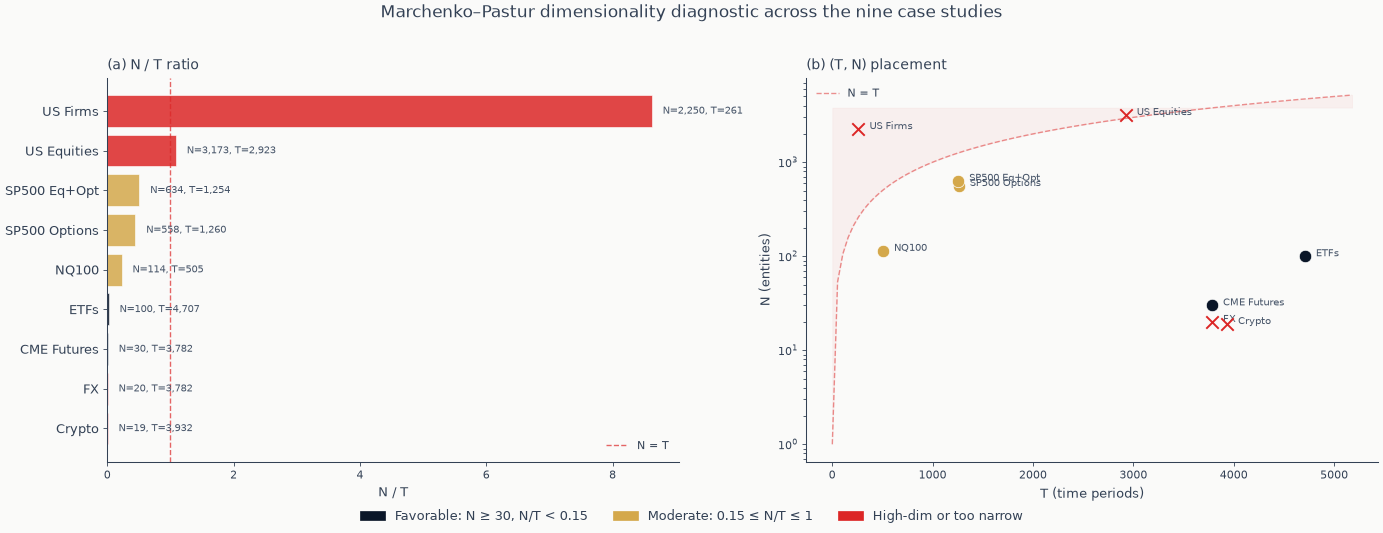

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_draw_panel_a(axes[0])
_draw_panel_b(axes[1])
handles_a = [
    plt.Rectangle(
        (0, 0), 1, 1, color=status_color["Favorable"], label="Favorable: N ≥ 30, N/T < 0.15"
    ),
    plt.Rectangle((0, 0), 1, 1, color=status_color["Moderate"], label="Moderate: 0.15 ≤ N/T ≤ 1"),
    plt.Rectangle(
        (0, 0), 1, 1, color=status_color["High-dimensional"], label="High-dim or too narrow"
    ),
]
fig.legend(
    handles=handles_a,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=9,
    frameon=False,
)
fig.suptitle(
    "Marchenko–Pastur dimensionality diagnostic across the nine case studies", fontsize=12, y=1.02
)
fig.tight_layout()
fig.show()

Three regimes appear. Crypto ($N=19$) and FX ($N=20$) sit below the
practical $N \ge 30$ floor — too few entities for a rank-stable covariance,
regardless of $T$. NASDAQ-100 ($N/T = 0.226$) and SP500 Options ($N/T =
0.443$) are in the moderate band but were not trained for latent factors at
this snapshot — the training pipeline runs only on the panels listed in
the registry. US Firm Characteristics ($N/T = 8.6$) and US Equities
($N/T = 1.1$) carry more entities than time periods: vanilla covariance is
dominated by the MP noise bulk, so only regularised methods (IPCA's
instrumented betas; CAE / SDF / SAE neural projections) are admissible
there. ETFs ($N/T = 0.021$), SP500 Eq+Opt ($N/T = 0.506$), and CME Futures
($N/T = 0.008$) are the favorable / moderate panels where vanilla PCA is
computable. The remainder of this notebook focuses on the five qualifying
panels — the ones the registry has populated with `latent_factors` runs.

In [13]:
QUALIFYING_CASE_STUDIES = [
    cs for cs in CASE_STUDY_IDS if not load_metrics_from_registry(cs, families=[FAMILY]).is_empty()
]
print(
    f"Qualifying case studies (latent_factors rows present in registry): "
    f"{[SHORT_NAMES[cs] for cs in QUALIFYING_CASE_STUDIES]}"
)

Qualifying case studies (latent_factors rows present in registry): ['ETFs', 'SP500 Eq+Opt', 'US Firms', 'CME Futures', 'US Equities']


### Coverage matrix: estimator × qualifying case study

The five PCA / IPCA / CAE / SDF / SAE estimators are not all trained on
every qualifying panel. CME Futures (narrow, long $T$) and US Equities
(wide $N$, long $T$) carry only their dimensionality-appropriate
estimators; ETFs and SP500 Eq+Opt carry the full grid; US Firm
Characteristics carries every estimator except PCA (the high-$N/T$ panel
where the unregularised covariance is uninformative).

In [14]:
coverage_rows = []
for cs in QUALIFYING_CASE_STUDIES:
    df = load_metrics_from_registry(cs, families=[FAMILY])
    cfgs = set(df["config_name"].unique().to_list())
    coverage_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            **{ESTIMATOR_DISPLAY[e]: ("✓" if e in cfgs else "—") for e in ESTIMATORS},
            "n_runs": df.height,
        }
    )
coverage_df = pl.DataFrame(coverage_rows)
print("Estimator × qualifying case-study coverage at any label:")
coverage_df

Estimator × qualifying case-study coverage at any label:


short_name,PCA,IPCA,CAE,SDF,SAE,n_runs
str,str,str,str,str,str,i64
"""ETFs""","""✓""","""✓""","""✓""","""✓""","""✓""",34
"""SP500 Eq+Opt""","""✓""","""✓""","""✓""","""✓""","""✓""",36
"""US Firms""","""—""","""✓""","""✓""","""✓""","""✓""",33
"""CME Futures""","""✓""","""—""","""—""","""✓""","""—""",20
"""US Equities""","""✓""","""✓""","""—""","""—""","""—""",6


## 2. Cross-CS Forest of Highest-IC Latent Configurations

For each qualifying case study, the estimator and configuration with the
highest daily-pooled IC on the primary label is plotted with its HAC 95 %
CI. Filled markers indicate $|t_{HAC}| > 2$ (CI excludes zero); open
markers indicate the CI overlaps zero.

In [15]:
lf_rank1 = collect_rank1_per_cs(QUALIFYING_CASE_STUDIES, family=FAMILY)
lf_rank1_display = lf_rank1.with_columns(
    estimator=pl.col("config_name").map_elements(display_estimator, return_dtype=pl.Utf8),
)
print(
    "Highest-IC latent-factor configuration per qualifying case study "
    "(primary label, daily-pooled IC ± HAC 95 % CI):"
)
lf_rank1_display.select(
    "short_name",
    "label",
    "estimator",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC latent-factor configuration per qualifying case study (primary label, daily-pooled IC ± HAC 95 % CI):


short_name,label,estimator,config_name,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,str,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""SDF""","""sdf""",0.0852,0.051,0.1194,4.89,2016
"""SP500 Eq+Opt""","""fwd_ret_5d""","""SDF""","""sdf""",0.0122,-0.0236,0.048,0.67,502
"""US Firms""","""fwd_ret_1m""","""SAE""","""sae""",0.062,0.0398,0.0841,5.54,110
"""CME Futures""","""fwd_ret_5d""","""SDF""","""sdf""",0.0373,0.0109,0.0637,2.77,1290
"""US Equities""","""fwd_ret_1d""","""IPCA""","""ipca""",0.0049,0.0006,0.0093,2.21,4018


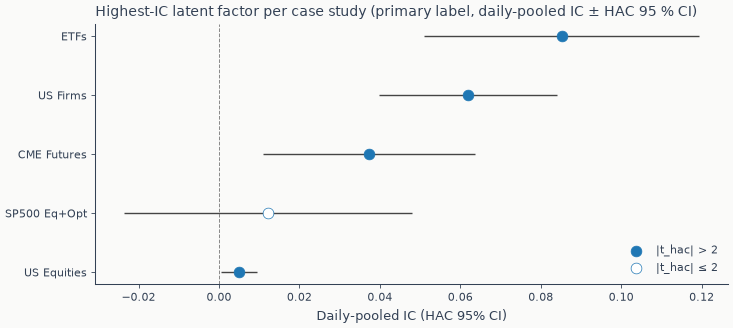

In [16]:
fig, _ = plot_cross_cs_forest(
    lf_rank1,
    family=FAMILY,
    title="Highest-IC latent factor per case study (primary label, daily-pooled IC ± HAC 95 % CI)",
)
fig.show()

In [17]:
n_total = lf_rank1.height
n_sig = int((lf_rank1["ic_t_hac"].abs() > 2.0).sum())
print(
    f"Latent-factor CI excludes zero ({{|t_HAC|>2}}) on {n_sig} of {n_total} qualifying case studies."
)

Latent-factor CI excludes zero ({|t_HAC|>2}) on 4 of 5 qualifying case studies.


Four of five qualifying panels carry an IC CI that strictly excludes
zero at the primary label: ETFs (SDF, $t_{HAC}=4.89$), CME Futures
(SDF, $t_{HAC}=2.77$), US Firm Characteristics (SAE, $t_{HAC}=5.54$),
and US Equities (IPCA, $t_{HAC}=2.21$, the marginal case). SP500 Eq+Opt
at the 5-day primary label is CI-overlap-zero on every estimator — its
credible non-zero latent signal lives at the
$\text{fwd\_ret\_risk\_adj\_5d}$ alternative label, picked up in §6.
The estimator that achieves the highest IC differs by panel: SDF on
ETFs, CME Futures, and SP500 Eq+Opt (at the primary label); SAE on
US Firms; IPCA on US Equities.

## 3. Within-Family Comparison

Three subsections trace the estimator grid: per-estimator IC inside each
qualifying case study (3a), aggregate by linear vs neural class (3b), and
the per-checkpoint trajectory of the highest-IC neural configuration (3c).

### 3a. Estimator × case-study heatmap

Within each qualifying case study, the highest IC achieved by each
estimator at the primary label is shown as a heatmap cell. Cells are blank
where the estimator was not trained on that case study — coverage gaps
remain visible.

In [18]:
heatmap_rows = []
for cs in QUALIFYING_CASE_STUDIES:
    primary = PRIMARY_LABELS[cs]
    df = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if df.is_empty():
        for est in ESTIMATORS:
            heatmap_rows.append(
                {"short_name": SHORT_NAMES[cs], "estimator": ESTIMATOR_DISPLAY[est], "ic": None}
            )
        continue
    by_est = (
        df.filter(pl.col("ic_mean_daily").is_not_null())
        .group_by("config_name")
        .agg(pl.col("ic_mean_daily").max().alias("ic"))
    )
    est_to_ic = dict(by_est.iter_rows())
    for est in ESTIMATORS:
        heatmap_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "estimator": ESTIMATOR_DISPLAY[est],
                "ic": est_to_ic.get(est),
            }
        )
heatmap_df = pl.DataFrame(heatmap_rows)
heatmap_pivot = heatmap_df.pivot(index="short_name", on="estimator", values="ic").sort("short_name")
est_cols = [ESTIMATOR_DISPLAY[e] for e in ESTIMATORS]
print(
    "Highest-IC latent-factor configuration per (case study × estimator) at the primary label "
    "(blank = estimator not trained on this case study):"
)
heatmap_pivot.select(["short_name", *est_cols])

Highest-IC latent-factor configuration per (case study × estimator) at the primary label (blank = estimator not trained on this case study):


short_name,PCA,IPCA,CAE,SDF,SAE
str,f64,f64,f64,f64,f64
"""CME Futures""",-0.015636,null,null,0.037287,null
"""ETFs""",0.027133,-0.008772,0.045903,0.08522,0.064219
"""SP500 Eq+Opt""",-0.012141,0.002421,0.00468,0.012186,0.011224
"""US Equities""",-0.004836,0.004949,null,null,null
"""US Firms""",null,-0.003864,-0.030129,0.014308,0.061974


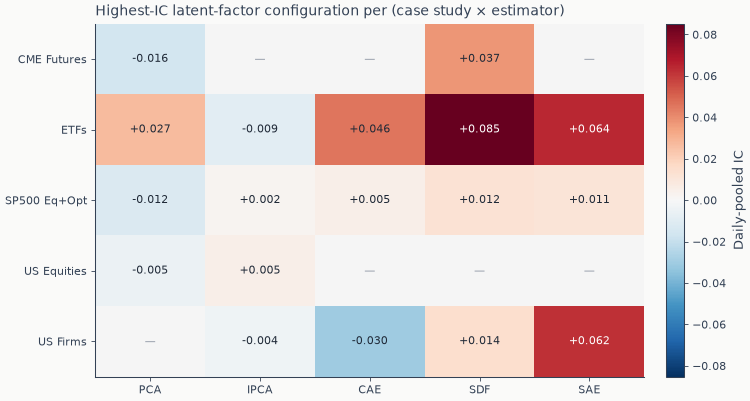

In [19]:
matrix_values = heatmap_pivot.select(est_cols).to_numpy().astype(float)
cs_labels = heatmap_pivot["short_name"].to_list()
fig, ax = plt.subplots(figsize=(7.5, 4))
finite_vals = matrix_values[np.isfinite(matrix_values)]
vmax = float(np.nanmax(np.abs(finite_vals))) if finite_vals.size else 0.05
masked = np.ma.array(matrix_values, mask=~np.isfinite(matrix_values))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="#f5f5f5")
im = ax.imshow(masked, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(est_cols)))
ax.set_xticklabels(est_cols)
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(est_cols)):
        v = matrix_values[i, j]
        if np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(v) > 0.6 * vmax else "#1f2937",
            )
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="#9ca3af")
ax.set_title("Highest-IC latent-factor configuration per (case study × estimator)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Daily-pooled IC")
fig.show()

Reading along rows, the per-CS estimator dispersion is wide on the panels
where neural estimators are trained: on US Firms the spread runs from CAE
at $-0.030$ to SAE at $+0.062$ — a $0.092$ IC swing inside the same
panel, more than two CI half-widths apart. On ETFs the linear and neural
estimators sit closer together (PCA $+0.027$ to SAE $+0.064$). On the
narrow-coverage panels the comparison reduces to two columns: CME Futures
(PCA vs SDF) and US Equities (PCA vs IPCA). Of the panels where PCA is
trained, only ETFs ($+0.027$) carries a positive PCA IC at the primary
label — the leading principal components track variance modes that
translate to directional rank information at the 21-day ETF horizon.
CME Futures, SP500 Eq+Opt, and US Equities all return non-positive PCA
IC at the primary horizon. (Section 6 returns to PCA at alternative
horizons.)

### 3b. Linear vs neural estimator class

Aggregating the heatmap by class, where do linear estimators (PCA, IPCA)
land relative to neural estimators (CAE, SDF, SAE)? The plot shows the
class-best IC per case study, with HAC 95 % CI bars where computable.

In [20]:
class_rows = []
for cs in QUALIFYING_CASE_STUDIES:
    primary = PRIMARY_LABELS[cs]
    df = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if df.is_empty():
        continue
    df = (
        df.filter(pl.col("ic_mean_daily").is_not_null())
        .with_columns(
            est_class=pl.col("config_name").replace_strict(ESTIMATOR_CLASS, default=None),
        )
        .filter(pl.col("est_class").is_not_null())
    )
    if df.is_empty():
        continue
    by_class = (
        df.sort("ic_mean_daily", descending=True)
        .group_by("est_class")
        .first()
        .select("est_class", "config_name", "ic_mean_daily", "ic_ci_lo", "ic_ci_hi", "ic_t_hac")
    )
    for r in by_class.iter_rows(named=True):
        class_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "est_class": r["est_class"],
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r["ic_ci_lo"],
                "ic_ci_hi": r["ic_ci_hi"],
                "ic_t_hac": r["ic_t_hac"],
            }
        )
class_df = pl.DataFrame(class_rows)
print("Highest IC per (case study × estimator class) at the primary label:")
class_df.sort(["short_name", "est_class"]).select(
    "short_name",
    "est_class",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
)

Highest IC per (case study × estimator class) at the primary label:


short_name,est_class,config_name,ic,t_hac
str,str,str,f64,f64
"""CME Futures""","""linear""","""pca""",-0.0156,-0.83
"""CME Futures""","""neural""","""sdf""",0.0373,2.77
"""ETFs""","""linear""","""pca""",0.0271,1.09
"""ETFs""","""neural""","""sdf""",0.0852,4.89
"""SP500 Eq+Opt""","""linear""","""ipca""",0.0024,0.16
"""SP500 Eq+Opt""","""neural""","""sdf""",0.0122,0.67
"""US Equities""","""linear""","""ipca""",0.0049,2.21
"""US Firms""","""linear""","""ipca""",-0.0039,-0.44
"""US Firms""","""neural""","""sae""",0.062,5.54


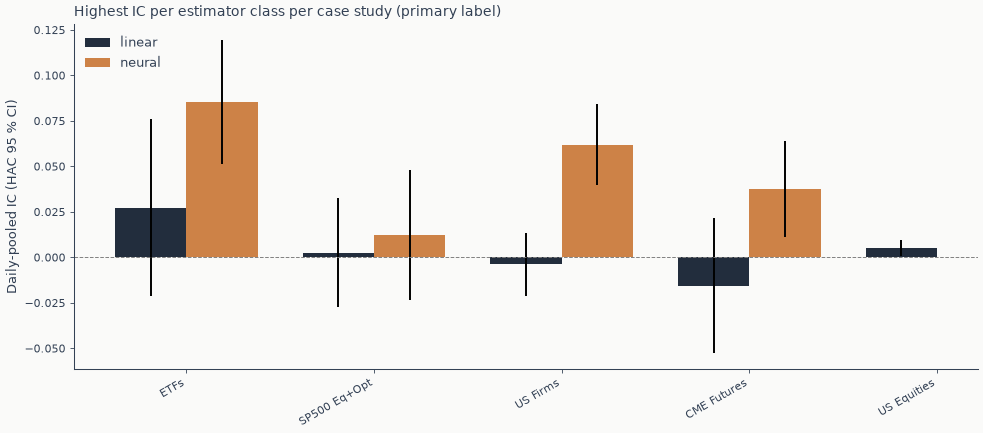

In [21]:
classes = ["linear", "neural"]
class_colors = {
    "linear": COLORS.get("blue", "#3B82F6"),
    "neural": COLORS.get("copper", "#B45309"),
}
cs_order_class = [
    SHORT_NAMES[cs]
    for cs in QUALIFYING_CASE_STUDIES
    if SHORT_NAMES[cs] in class_df["short_name"].to_list()
]
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(cs_order_class))
width = 0.38
for i, cls in enumerate(classes):
    sub = class_df.filter(pl.col("est_class") == cls)
    ic = []
    err_lo = []
    err_hi = []
    for cs in cs_order_class:
        row = sub.filter(pl.col("short_name") == cs)
        if row.height == 0:
            ic.append(np.nan)
            err_lo.append(0.0)
            err_hi.append(0.0)
        else:
            r = row.row(0, named=True)
            ic.append(r["ic_mean_daily"])
            err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
            err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
    ic_a = np.array(ic, dtype=float)
    ax.bar(
        x + (i - 0.5) * width,
        ic_a,
        width=width,
        yerr=np.vstack([err_lo, err_hi]),
        capsize=2,
        color=class_colors[cls],
        alpha=0.9,
        label=cls,
    )
ax.set_xticks(x)
ax.set_xticklabels(cs_order_class, rotation=30, ha="right")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("Highest IC per estimator class per case study (primary label)")
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
fig.show()

In [22]:
class_top_per_cs = (
    class_df.sort("ic_mean_daily", descending=True)
    .group_by("short_name")
    .first()
    .group_by("est_class")
    .agg(n_cs_with_highest_ic=pl.col("short_name").len())
    .sort("n_cs_with_highest_ic", descending=True)
)
print("Estimator class achieving the highest IC per case study (count, primary label):")
class_top_per_cs

Estimator class achieving the highest IC per case study (count, primary label):


est_class,n_cs_with_highest_ic
str,u32
"""neural""",4
"""linear""",1


Aggregating by class, neural estimators carry the class-highest IC on
four of five qualifying case studies (ETFs, CME Futures, US Firms, SP500
Eq+Opt); linear estimators carry the class-highest on one (US Equities,
the high-$N$ panel where IPCA's instrumented-beta formulation has the
most cross-sectional variation to work with). The class gap is small on
ETFs and SP500 Eq+Opt (within one CI half-width) and large on US Firms,
where the SAE multi-task objective extracts a $+0.062$ IC on a panel
where the linear class tops out at IPCA's $-0.004$.

### 3c. Neural training dynamics

CAE, SDF, and SAE are neural networks; their per-checkpoint IC trajectory
(loaded from `fold_metrics`) reveals whether the training schedule is
converging cleanly or whether the highest-IC checkpoint is the one
that happened to land on a transient peak. The plot shows the median IC across
folds (with IQR band) for each (CS, estimator) where ≥ 2 checkpoints are
stored.

In [23]:
ckpt_rows = []
for cs in QUALIFYING_CASE_STUDIES:
    primary = PRIMARY_LABELS[cs]
    fm = load_fold_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if fm.is_empty():
        continue
    fm = fm.filter(
        pl.col("config_name").is_in(["cae", "sdf", "sae"])
        & pl.col("checkpoint_value").is_not_null()
    )
    if fm.is_empty():
        continue
    agg = (
        fm.group_by(["config_name", "checkpoint_value"])
        .agg(
            ic_median=pl.col("ic").median(),
            ic_q25=pl.col("ic").quantile(0.25),
            ic_q75=pl.col("ic").quantile(0.75),
            n_folds=pl.col("ic").count(),
        )
        .filter(pl.col("n_folds") >= 1)
        .sort(["config_name", "checkpoint_value"])
        .with_columns(
            pl.lit(SHORT_NAMES[cs]).alias("short_name"),
            pl.lit(cs).alias("case_study"),
        )
    )
    ckpt_rows.append(agg)
ckpt_df = pl.concat(ckpt_rows) if ckpt_rows else pl.DataFrame()

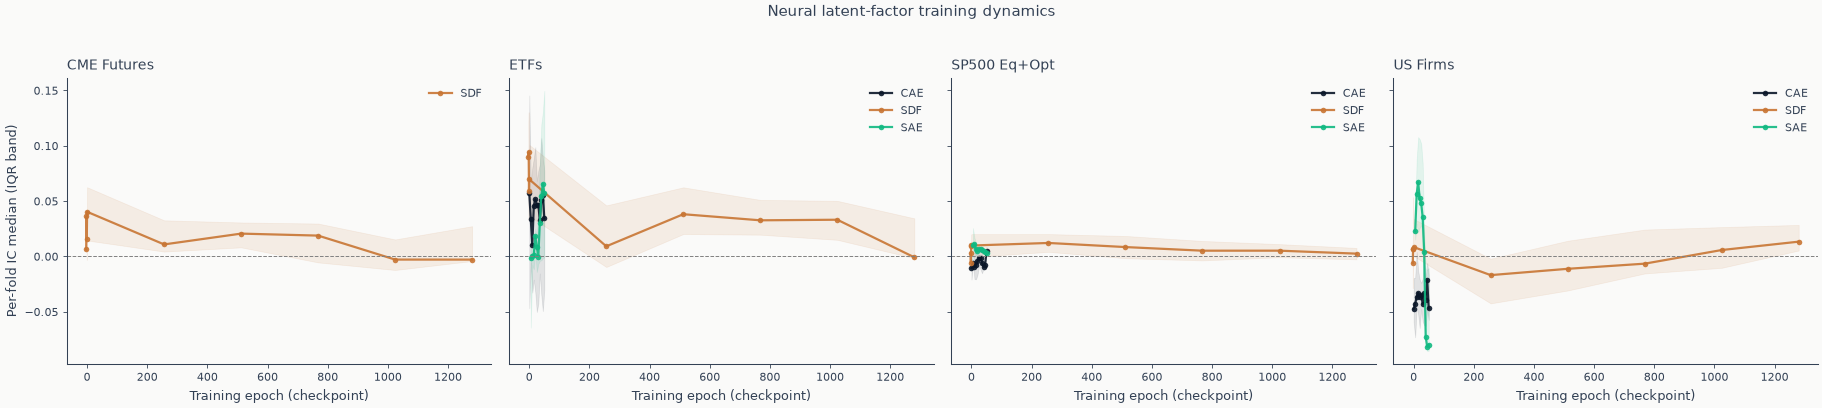

In [24]:
if not ckpt_df.is_empty():
    cs_present = sorted(ckpt_df["short_name"].unique().to_list())
    n_panels = len(cs_present)
    fig, axes = plt.subplots(1, n_panels, figsize=(4.6 * n_panels, 4), squeeze=False, sharey=True)
    est_color = {
        "cae": COLORS.get("blue", "#3B82F6"),
        "sdf": COLORS.get("copper", "#B45309"),
        "sae": COLORS.get("positive", "#10B981"),
    }
    for idx, cs_name in enumerate(cs_present):
        ax = axes[0, idx]
        sub = ckpt_df.filter(pl.col("short_name") == cs_name)
        for est in ["cae", "sdf", "sae"]:
            est_sub = sub.filter(pl.col("config_name") == est).sort("checkpoint_value")
            if est_sub.height < 2:
                continue
            x = est_sub["checkpoint_value"].to_numpy()
            med = est_sub["ic_median"].to_numpy()
            q25 = est_sub["ic_q25"].to_numpy()
            q75 = est_sub["ic_q75"].to_numpy()
            color = est_color[est]
            ax.fill_between(x, q25, q75, color=color, alpha=0.10)
            ax.plot(
                x,
                med,
                "o-",
                color=color,
                label=ESTIMATOR_DISPLAY[est],
                linewidth=1.6,
                markersize=4,
                alpha=0.9,
            )
        ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
        ax.set_xlabel("Training epoch (checkpoint)")
        if idx == 0:
            ax.set_ylabel("Per-fold IC median (IQR band)")
        ax.set_title(cs_name, fontsize=10)
        ax.legend(frameon=False, fontsize=8, loc="best")
    fig.suptitle("Neural latent-factor training dynamics", y=1.03)
    fig.tight_layout()
    fig.show()
else:
    print("No neural-LF checkpoint data available.")

The trajectories make the per-case-study character of the neural
estimators visible. On US Firms the SAE curve climbs from near zero at
epoch 1 to $\approx +0.06$ by the final epoch and is the only neural
estimator with a monotonically positive trajectory; CAE drifts
progressively negative — symptomatic of an autoencoder repurposed for
forecasting (Section 14.6). On ETFs both SAE and SDF stabilise above zero
after a short warm-up; on SP500 Eq+Opt the IQR bands span zero throughout
training. Trajectory shape, not just final-checkpoint level, is what the
headline IC metric in §2 distills into a single number.

## 4. Stability and Uncertainty

The headline metric is daily-pooled IC with HAC CI (§2). Per-fold IC is
the stability diagnostic; §4b drills into US Firm Characteristics where
all four neural objectives are trained on the same panel.

### 4a. Per-fold IC distribution

For each qualifying case study, the per-fold IC distribution of the
highest-IC latent configuration is shown as a box-plus-scatter, sorted
left-to-right by headline IC.

In [25]:
lf_fold = collect_fold_ic_per_cs(QUALIFYING_CASE_STUDIES, family=FAMILY)
lf_fold_summary = (
    lf_fold.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC latent-factor configuration (primary label):")
lf_fold_summary

Per-fold IC summary for the highest-IC latent-factor configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""etfs""","""ETFs""",8,0.094228,0.067581,0.875
"""us_firm_characteristics""","""US Firms""",10,0.06707,0.039675,1.0
"""cme_futures""","""CME Futures""",5,0.040366,0.029693,1.0
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.012186,0.011352,1.0
"""us_equities_panel""","""US Equities""",16,0.002519,0.011983,0.625


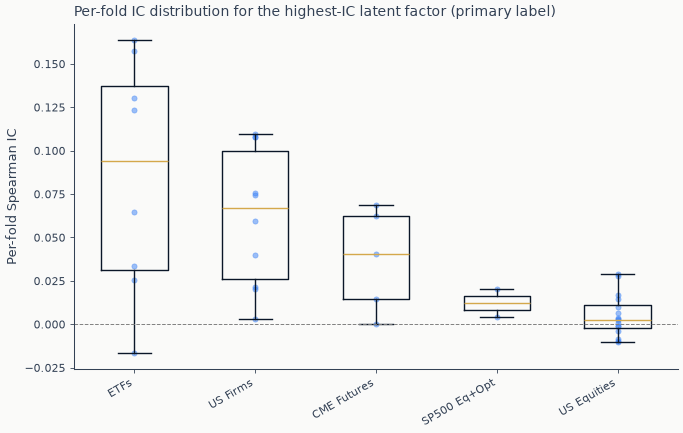

In [26]:
order = lf_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
fig, _ = plot_per_fold_violin(
    lf_fold,
    order=order,
    title="Per-fold IC distribution for the highest-IC latent factor (primary label)",
)
fig.show()

Three of the five qualifying panels are uniformly positive across folds
at the highest-IC configuration — US Firms 100 % (10 folds, median
$+0.067$), CME Futures 100 % (5 folds, median $+0.036$), SP500 Eq+Opt
100 % (2 folds, median $+0.014$) — while ETFs (62.5 %, 8 folds, median
$+0.057$) and US Equities (62.5 %, 16 folds, median $+0.003$) are
positive majorities. Fold count is uneven
across panels (2 to
16 folds depending on each case study's CV schedule); the SP500 Eq+Opt
100 % rate sits behind only two folds, so per-fold spread is a
diagnostic for stability rather than a substitute for the daily-pooled
HAC CI in §2.

### 4b. US Firm Characteristics objective ladder

US Firms is the one qualifying panel where all four neural objectives —
reconstruction (CAE), no-arbitrage (SDF), multi-task (SAE) — were trained
alongside the linear class (IPCA). The chapter introduces an *objective
ladder* hypothesis: estimators that target the risk-premium component of
covariance (SDF, CAE) should outperform variance maximisers when
predicting forward returns. The empirics here speak directly to whether
the ladder is partially ordered on real data.

In [27]:
ladder_order = ["ipca", "cae", "sdf", "sae"]
us_firms_data = load_metrics_from_registry(
    "us_firm_characteristics", label="fwd_ret_1m", families=[FAMILY]
).filter(pl.col("ic_mean_daily").is_not_null())

ladder_rows = []
for est in ladder_order:
    sub = us_firms_data.filter(pl.col("config_name") == est)
    if sub.is_empty():
        continue
    best = sub.sort("ic_mean_daily", descending=True).head(1).row(0, named=True)
    ladder_rows.append(
        {
            "estimator": ESTIMATOR_DISPLAY[est],
            "objective": ESTIMATOR_OBJECTIVE[est],
            "ic": best["ic_mean_daily"],
            "ci_lo": best["ic_ci_lo"],
            "ci_hi": best["ic_ci_hi"],
            "t_hac": best["ic_t_hac"],
        }
    )
ladder_df = pl.DataFrame(ladder_rows)
print("US Firm Characteristics objective ladder (fwd_ret_1m, daily-pooled IC ± HAC 95 % CI):")
ladder_df.select(
    "estimator",
    "objective",
    pl.col("ic").round(4).alias("ic"),
    pl.col("ci_lo").round(4).alias("ci_lo"),
    pl.col("ci_hi").round(4).alias("ci_hi"),
    pl.col("t_hac").round(2).alias("t_hac"),
)

US Firm Characteristics objective ladder (fwd_ret_1m, daily-pooled IC ± HAC 95 % CI):


estimator,objective,ic,ci_lo,ci_hi,t_hac
str,str,f64,f64,f64,f64
"""IPCA""","""characteristic-instrumented variance""",-0.0039,-0.0213,0.0136,-0.44
"""CAE""","""reconstruction""",-0.0301,-0.0512,-0.009,-2.83
"""SDF""","""no-arbitrage (pricing kernel)""",0.0143,-0.0104,0.039,1.15
"""SAE""","""multi-task (reconstruction + prediction)""",0.062,0.0398,0.0841,5.54


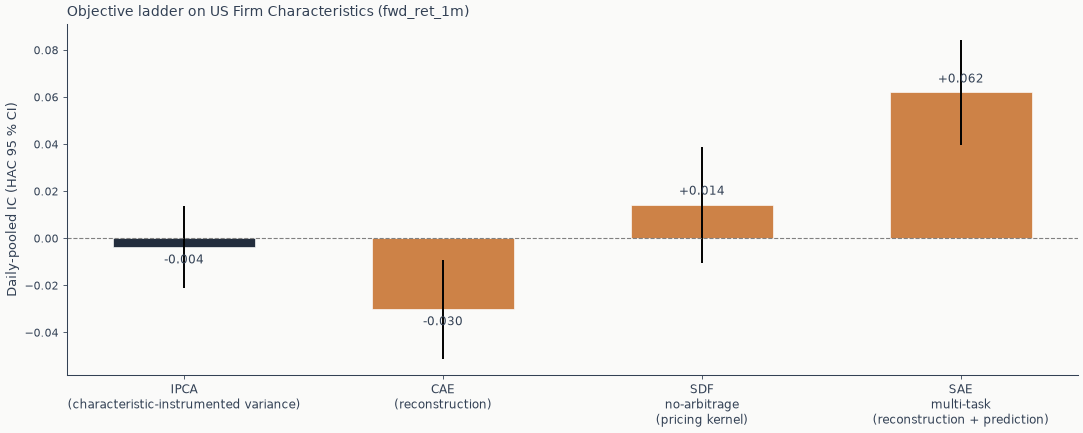

In [28]:
fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(ladder_df))
ic_vals = ladder_df["ic"].to_numpy()
err_lo = ic_vals - ladder_df["ci_lo"].to_numpy()
err_hi = ladder_df["ci_hi"].to_numpy() - ic_vals
class_to_color = {
    "IPCA": class_colors["linear"],
    "CAE": class_colors["neural"],
    "SDF": class_colors["neural"],
    "SAE": class_colors["neural"],
}
bar_colors = [class_to_color[e] for e in ladder_df["estimator"].to_list()]
ax.bar(
    xs,
    ic_vals,
    yerr=np.vstack([err_lo, err_hi]),
    capsize=4,
    width=0.55,
    color=bar_colors,
    alpha=0.9,
    edgecolor="white",
)
ax.set_xticks(xs)
# Wrap long objective labels at the parenthesis to keep tick labels from colliding.
_wrapped_labels = []
for e, o in zip(ladder_df["estimator"].to_list(), ladder_df["objective"].to_list(), strict=False):
    if "(" in o:
        head, tail = o.split("(", 1)
        _wrapped_labels.append(f"{e}\n{head.strip()}\n({tail}")
    else:
        _wrapped_labels.append(f"{e}\n({o})")
ax.set_xticklabels(_wrapped_labels, fontsize=8.5)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("Objective ladder on US Firm Characteristics (fwd_ret_1m)")
for x, ic in zip(xs, ic_vals, strict=False):
    ax.text(
        x,
        ic + (0.003 if ic >= 0 else -0.003),
        f"{ic:+.3f}",
        ha="center",
        va="bottom" if ic >= 0 else "top",
        fontsize=8.5,
    )
fig.tight_layout()
fig.show()

The ladder hypothesis predicts SDF $\succ$ CAE $\succ$ IPCA on a panel
where pricing-error objectives align with forward-return prediction. The
empirical ordering on US Firms is SAE $+0.062$ > SDF $+0.014$ > IPCA
$-0.004$ > CAE $-0.030$ — SAE achieves the highest IC, SDF's IC CI
overlaps zero, and CAE sits below the linear baseline. The likely
mechanisms: CAE minimises cross-sectional return reconstruction
$\|R - \hat R\|^2$, dominated by the market mode and volatility — a known
repurposing-failure for forecasting (Section 14.6;
`feedback_cae_prediction_protocol`). SDF's adversarial pricing kernel is
unstable when $T = 261$ — the discriminator is signal-starved on a panel
this wide and short. SAE's auxiliary supervised loss anchors the encoder
to forward returns directly, which on this panel is enough to dominate
the reconstruction term's pull toward variance modes. The ordering
reverses parts of the ladder: which objective achieves the highest IC is
empirical and panel-dependent, not theoretical.

## 5. Latent Factors versus Supervised Baselines

At the primary label, how does the highest-IC latent-factor configuration
compare to the strongest supervised baseline (max of linear, GBM, TabM,
deep learning)? The scatter plots the strongest-supervised IC on the
x-axis and the highest latent-factor IC on the y-axis. Marker fill
encodes whether the paired-fold bootstrap CI for the delta excludes zero.

`family_rank1` returns the highest-IC configuration per qualifying case
study within a single supervised family (linear, GBM, TabM, or deep
learning), keyed by `case_study` and `config_name`.

In [29]:
def family_rank1(family: str) -> pl.DataFrame:
    df = collect_rank1_per_cs(QUALIFYING_CASE_STUDIES, family=family)
    if df.is_empty():
        return pl.DataFrame()
    return df.select(
        "case_study",
        "short_name",
        "config_name",
        pl.col("ic_mean_daily").alias(f"{family}_ic"),
    )

Materialise the rank-1 IC and the per-fold IC frames for each supervised
baseline. The per-fold frames feed the paired-fold bootstrap below.

In [30]:
fam_to_ic_df = {f: family_rank1(f) for f in SUPERVISED_BASELINES}
fam_to_fold = {
    f: collect_fold_ic_per_cs(QUALIFYING_CASE_STUDIES, family=f) for f in SUPERVISED_BASELINES
}

For each qualifying case study, pick the strongest supervised baseline by
IC, align it with the highest-IC latent configuration on the shared fold
set, and bootstrap the paired-fold delta CI ($N_{\text{boot}}$ = 1000).

A small helper picks the strongest supervised baseline by rank-1 IC on a
given case study, returning `(family, IC)` or `None` if no baseline is
registered.

In [31]:
def _best_supervised_family(cs: str) -> tuple[str, float] | None:
    """Return (family, IC) of the strongest supervised baseline on this case study."""
    fam_ics = {}
    for fam in SUPERVISED_BASELINES:
        df = fam_to_ic_df[fam]
        if df.is_empty():
            continue
        sub = df.filter(pl.col("case_study") == cs)
        if sub.is_empty():
            continue
        fam_ics[fam] = sub.row(0, named=True)[f"{fam}_ic"]
    if not fam_ics:
        return None
    best_fam = max(fam_ics, key=fam_ics.get)
    return best_fam, fam_ics[best_fam]

In [32]:
delta_rows = []
rng = np.random.default_rng(RNG_SEED)
for cs in QUALIFYING_CASE_STUDIES:
    lf_row = lf_rank1.filter(pl.col("case_study") == cs)
    if lf_row.is_empty():
        continue
    lf_ic = lf_row.row(0, named=True)["ic_mean_daily"]
    lf_estimator = display_estimator(lf_row.row(0, named=True)["config_name"])

    best = _best_supervised_family(cs)
    if best is None:
        continue
    best_fam, best_baseline_ic = best

    base_fold = fam_to_fold[best_fam]
    if base_fold.is_empty():
        continue
    paired = (
        lf_fold.filter(pl.col("case_study") == cs)
        .select("fold_id", pl.col("ic").alias("lf_ic"))
        .join(
            base_fold.filter(pl.col("case_study") == cs).select(
                "fold_id", pl.col("ic").alias("base_ic")
            ),
            on="fold_id",
            how="inner",
        )
    )
    if paired.height < 2:
        continue
    deltas = paired["lf_ic"].to_numpy() - paired["base_ic"].to_numpy()
    boot = rng.choice(deltas, size=(N_BOOT, len(deltas)), replace=True).mean(axis=1)
    delta_rows.append(
        {
            "case_study": cs,
            "short_name": SHORT_NAMES[cs],
            "lf_estimator": lf_estimator,
            "lf_ic": lf_ic,
            "best_baseline_family": best_fam,
            "best_baseline_ic": best_baseline_ic,
            "n_paired_folds": len(deltas),
            "mean_delta": float(np.mean(deltas)),
            "boot_lo": float(np.percentile(boot, 2.5)),
            "boot_hi": float(np.percentile(boot, 97.5)),
        }
    )

Materialise the per-CS delta table and report the LF IC, supervised IC,
bootstrap-CI bounds, and paired-fold count for each qualifying panel.

In [33]:
delta_df = pl.DataFrame(delta_rows).sort("mean_delta", descending=True)
print("Latent factor minus strongest supervised baseline (paired-fold bootstrap, primary label):")
delta_df.select(
    "short_name",
    "lf_estimator",
    "best_baseline_family",
    pl.col("lf_ic").round(4).alias("lf"),
    pl.col("best_baseline_ic").round(4).alias("base"),
    "n_paired_folds",
    pl.col("mean_delta").round(4).alias("delta"),
    pl.col("boot_lo").round(4).alias("boot_lo"),
    pl.col("boot_hi").round(4).alias("boot_hi"),
)

Latent factor minus strongest supervised baseline (paired-fold bootstrap, primary label):


short_name,lf_estimator,best_baseline_family,lf,base,n_paired_folds,delta,boot_lo,boot_hi
str,str,str,f64,f64,i64,f64,f64,f64
"""ETFs""","""SDF""","""deep_learning""",0.0852,0.0622,8,0.023,-0.0208,0.0635
"""CME Futures""","""SDF""","""gbm""",0.0373,0.0322,5,0.0051,-0.0224,0.0426
"""SP500 Eq+Opt""","""SDF""","""tabular_dl""",0.0122,0.0114,2,0.0008,-0.009,0.0107
"""US Firms""","""SAE""","""gbm""",0.062,0.0803,10,-0.0183,-0.0431,0.0021
"""US Equities""","""IPCA""","""gbm""",0.0049,0.0318,16,-0.0269,-0.0332,-0.0204


Build a custom legend that decodes the marker shapes (one shape per
supervised baseline family) and the fill colours (filled = bootstrap CI
excludes zero in either direction; hollow = CI overlaps zero).

In [34]:
fam_marker = {"linear": "o", "gbm": "s", "tabular_dl": "D", "deep_learning": "P"}
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC supervised = Linear",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC supervised = GBM",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC supervised = TabM",
    ),
    Line2D(
        [0],
        [0],
        marker="P",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC supervised = DL",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS.get("positive", "#10B981"),
        markeredgecolor="#1f77b4",
        markersize=9,
        label="LF IC > supervised IC, CI excludes 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS.get("negative", "#EF4444"),
        markeredgecolor="#1f77b4",
        markersize=9,
        label="LF IC < supervised IC, CI excludes 0",
    ),
    Line2D([0], [0], color="gray", linestyle="--", label="LF IC = supervised IC"),
]

Render the scatter: x = highest-IC supervised baseline, y = highest-IC
latent factor, marker shape = baseline family, fill = CI verdict, the
diagonal traces LF IC = supervised IC.

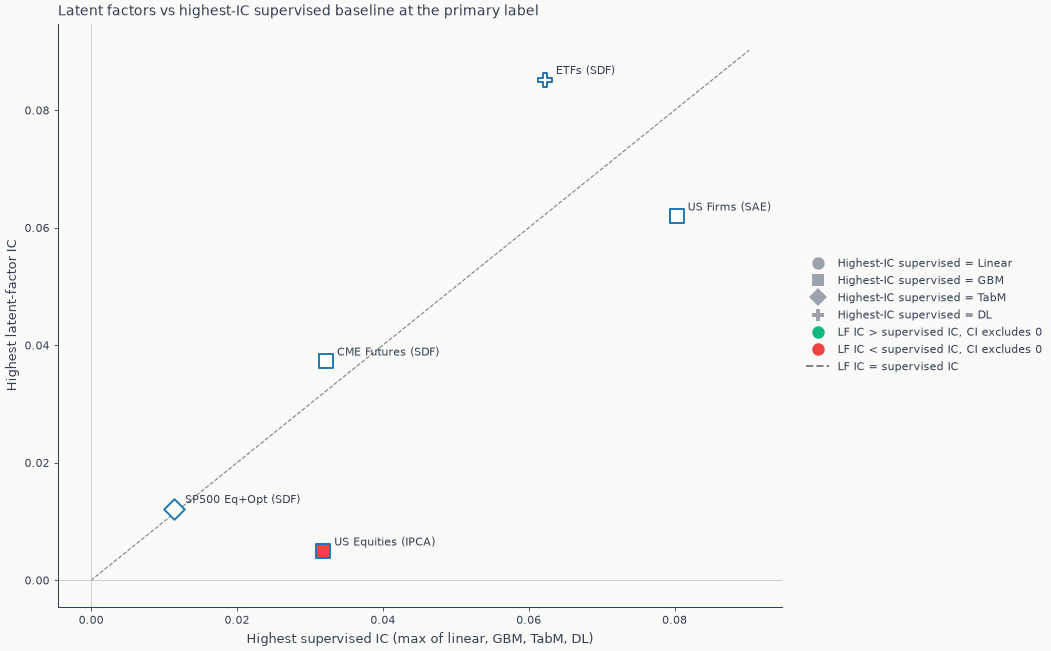

In [35]:
fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
xs = delta_df["best_baseline_ic"].to_numpy()
ys = delta_df["lf_ic"].to_numpy()
los = delta_df["boot_lo"].to_numpy()
his = delta_df["boot_hi"].to_numpy()
sig = (los > 0) | (his < 0)
fams = delta_df["best_baseline_family"].to_list()
names = delta_df["short_name"].to_list()
ests = delta_df["lf_estimator"].to_list()

for x, y, name, est, fam, s in zip(xs, ys, names, ests, fams, sig, strict=False):
    if s and y > x:
        facecolor = COLORS.get("positive", "#10B981")
    elif s and y < x:
        facecolor = COLORS.get("negative", "#EF4444")
    else:
        facecolor = "white"
    ax.scatter(
        x,
        y,
        s=110,
        marker=fam_marker.get(fam, "o"),
        facecolor=facecolor,
        edgecolor="#1f77b4",
        linewidth=1.4,
        zorder=3,
    )
    ax.annotate(f"{name} ({est})", (x, y), textcoords="offset points", xytext=(8, 4), fontsize=8)

lo = float(min(np.min(xs), np.min(ys))) - 0.005
hi = float(max(np.max(xs), np.max(ys))) + 0.005
ax.plot(
    [lo, hi], [lo, hi], color="gray", linewidth=0.8, linestyle="--", label="LF IC = supervised IC"
)
ax.axhline(0, color="#bbb", linewidth=0.5)
ax.axvline(0, color="#bbb", linewidth=0.5)
ax.set_xlabel("Highest supervised IC (max of linear, GBM, TabM, DL)")
ax.set_ylabel("Highest latent-factor IC")
ax.set_title("Latent factors vs highest-IC supervised baseline at the primary label")
ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=8,
)
fig.show()

In [36]:
n_above = int((ys > xs).sum())
n_sig_above = int(((ys > xs) & sig).sum())
n_sig_below = int(((ys < xs) & sig).sum())
print(
    f"Highest-IC latent factor exceeds highest-IC supervised baseline on "
    f"{n_above}/{len(ys)} qualifying case studies; paired-fold bootstrap CI "
    f"excludes zero (LF above) on {n_sig_above}, (LF below) on {n_sig_below}."
)

Highest-IC latent factor exceeds highest-IC supervised baseline on 3/5 qualifying case studies; paired-fold bootstrap CI excludes zero (LF above) on 0, (LF below) on 1.


One qualifying panel carries a credibly negative paired-fold delta: US
Equities (IPCA $+0.005$ vs GBM $+0.032$, delta CI $[-0.033, -0.020]$,
16 paired folds — the tightest CI of the five). US Firms is the
next-strongest negative point estimate (SAE $+0.062$ vs GBM $+0.080$,
delta $-0.018$, CI $[-0.043, +0.002]$) but the bootstrap CI just
crosses zero. On the remaining three panels (ETFs vs DL, CME Futures
vs GBM, SP500 Eq+Opt vs TabM) the highest-IC latent factor's edge over the
strongest supervised baseline is positive but modest (ETFs $+0.023$, CME
Futures $+0.005$, SP500 Eq+Opt $+0.001$) and the bootstrap CI is
wide relative to the difference: the latent factor is statistically
indistinguishable from the strongest supervised configuration on the
same fold set. The frequency / universe diagnostics from §1 line up
with the cross-section: US Equities ($N=3173$) is the panel where a
tabular learner can fit non-linear interactions in raw characteristics
most decisively, and it is also the only panel where the bootstrap
delta-CI for the highest-IC latent factor lies entirely below zero.

## 6. Multi-Label Horizon View

Every qualifying panel was trained at $\geq 2$ labels: ETFs at 5d/21d,
CME Futures at 5d/21d, US Equities at 1d/5d/21d, SP500 Eq+Opt at
5d/10d/risk-adjusted-5d, US Firms at fwd_ret_1m / fwd_ret_1m_win /
fwd_class_1m. The plot shows the highest latent-factor IC for each qualifying
(CS, label) pair, with HAC 95 % CI bands. The classification label
(`fwd_class_1m`) and the risk-adjusted label
(`fwd_ret_risk_adj_5d`) appear as separate horizons via the shared
`HORIZON_DAYS` mapping in the helper module.

`regression_labels` returns the regression-style forward-return labels
available for a case study in the registry (forward-return columns plus
`ret_to_expiry` for the options panel). Classification labels are excluded
to keep the horizon axis comparable across panels.

In [37]:
def regression_labels(cs: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[FAMILY])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None and (lbl.startswith("fwd_ret_") or lbl == "ret_to_expiry")
    ]

Collect the highest-IC latent configuration per (case study, regression
label) cell.

In [38]:
lf_horizon = collect_multi_label_per_cs(
    QUALIFYING_CASE_STUDIES, family=FAMILY, labels=regression_labels
)
print(
    f"Latent-factor multi-label horizon coverage: {lf_horizon.height} (CS, label) cells "
    f"across {lf_horizon['case_study'].n_unique() if not lf_horizon.is_empty() else 0} case studies."
)

Latent-factor multi-label horizon coverage: 12 (CS, label) cells across 5 case studies.


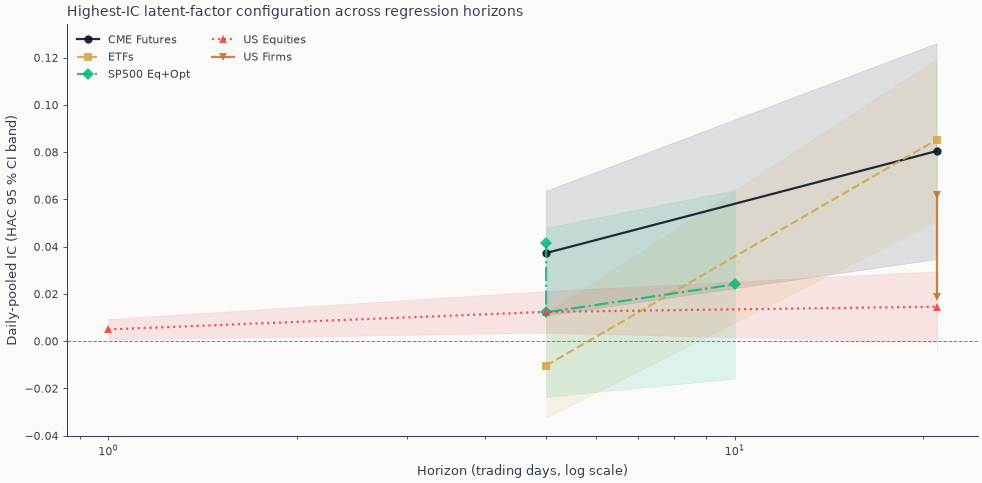

In [39]:
multi_horizon_cs = (
    lf_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
if multi_horizon_cs:
    # COLORS.values() includes near-white shades (silver, bg_light) that wash out
    # against the figure background. Pass an explicit high-contrast palette.
    _horizon_palette = [
        COLORS["blue"],
        COLORS["amber"],
        COLORS["positive"],
        COLORS["negative"],
        COLORS["copper"],
        COLORS["slate"],
        COLORS["neutral"],
    ]
    fig, _ = plot_multi_label_horizon(
        lf_horizon,
        title="Highest-IC latent-factor configuration across regression horizons",
        palette=_horizon_palette,
    )
    fig.show()
else:
    print("Fewer than two horizon-mapped labels per qualifying CS — degenerate.")

Four patterns emerge. On ETFs the highest-IC latent configuration
jumps from IPCA's $-0.010$ at 5 days to SDF's $+0.085$ at 21 days — a
horizon transition in both magnitude and choice of estimator. On US
Equities IPCA's IC rises with horizon (1d $+0.005$, 5d $+0.012$, 21d
$+0.015$); the conditional-beta formulation extracts a small but
horizon-stable signal that improves at slower horizons. On CME Futures
the SDF objective carries the highest IC at both horizons — $+0.037$
at 5 days ($t_{HAC}=2.77$) and $+0.080$ at 21 days ($t_{HAC}=3.45$),
both with HAC CIs that exclude zero — while PCA stays near zero at
both horizons ($-0.016$ at 5d, $+0.005$ at 21d): the variance-mode
estimator is uninformative on this panel at either horizon. SP500
Eq+Opt is the noteworthy heterogeneity case: the highest latent IC is
essentially zero at the 5-day primary label but jumps to IPCA's
$+0.041$ on the risk-adjusted 5-day label, with $|t_{HAC}|=3.21$. The
risk-adjusted target absorbs the option-implied volatility variation
that the raw 5-day return label does not.

## 7. Structural Diagnostics

Two single-CS diagnostics complete the cross-CS view: the prediction
agreement among CAE / SDF / SAE on US Firms (an ensemble-design input
for Ch20), and a CME-Futures deep dive that explains why SDF wins on
the panel with the most favorable $N/T$.

### 7a. Model agreement on US Firm Characteristics

If the three neural latent estimators rank entities similarly, ensemble
averaging across them adds little beyond noise reduction. If they
disagree, each is capturing a distinct aspect of the cross-section —
the case for a multi-objective ensemble in Ch20.

Identify the highest-IC checkpoint per neural estimator on US Firms, then
load the per-entity predictions from each.

In [40]:
us_firms_preds = {}
us_firms_rank1_per_est = (
    load_metrics_from_registry("us_firm_characteristics", label="fwd_ret_1m", families=[FAMILY])
    .filter(
        pl.col("config_name").is_in(["cae", "sdf", "sae"]) & pl.col("ic_mean_daily").is_not_null()
    )
    .sort("ic_mean_daily", descending=True)
    .group_by("config_name")
    .first()
    .select("config_name", "checkpoint_value")
)
for r in us_firms_rank1_per_est.iter_rows(named=True):
    p = load_predictions(
        "us_firm_characteristics",
        family=FAMILY,
        label="fwd_ret_1m",
        config_name=r["config_name"],
        checkpoint_value=r["checkpoint_value"],
    )
    if p.is_empty():
        continue
    us_firms_preds[r["config_name"]] = p

Compute pairwise Spearman rank correlations across the neural estimators
by aligning predictions on the shared `(timestamp, symbol, fold_id)` key.

In [41]:
if len(us_firms_preds) >= 2:
    estimators = sorted(us_firms_preds.keys())
    n = len(estimators)
    corr_matrix = np.full((n, n), np.nan)
    for i, e1 in enumerate(estimators):
        for j, e2 in enumerate(estimators):
            if i == j:
                corr_matrix[i, j] = 1.0
                continue
            left = us_firms_preds[e1].select(
                "timestamp", "symbol", "fold_id", pl.col("y_score").alias("y1")
            )
            right = us_firms_preds[e2].select(
                "timestamp", "symbol", "fold_id", pl.col("y_score").alias("y2")
            )
            joined = left.join(right, on=["timestamp", "symbol", "fold_id"])
            if joined.height > 0:
                corr_matrix[i, j] = joined.select(pl.corr("y1", "y2", method="spearman")).item()
    print(
        "Pairwise rank correlation across US Firms neural latent estimators "
        "(highest-IC checkpoint each, primary label):"
    )
    out_cols = {
        ESTIMATOR_DISPLAY[e]: [round(corr_matrix[i, j], 3) for j in range(n)]
        for i, e in enumerate(estimators)
    }
    out = pl.DataFrame({"estimator": [ESTIMATOR_DISPLAY[e] for e in estimators], **out_cols})
    print(out)
else:
    print(
        "Fewer than two neural latent estimators with predictions on US Firms — "
        "agreement diagnostic skipped."
    )

Pairwise rank correlation across US Firms neural latent estimators (highest-IC checkpoint each, primary label):
shape: (3, 4)
┌───────────┬────────┬────────┬───────┐
│ estimator ┆ CAE    ┆ SAE    ┆ SDF   │
│ ---       ┆ ---    ┆ ---    ┆ ---   │
│ str       ┆ f64    ┆ f64    ┆ f64   │
╞═══════════╪════════╪════════╪═══════╡
│ CAE       ┆ 1.0    ┆ -0.297 ┆ 0.043 │
│ SAE       ┆ -0.297 ┆ 1.0    ┆ -0.02 │
│ SDF       ┆ 0.043  ┆ -0.02  ┆ 1.0   │
└───────────┴────────┴────────┴───────┘


Pairwise Spearman rank correlations across the three neural objectives
read out the diversity of the underlying decompositions. The CAE–SAE
pair carries the largest absolute correlation and it is negative
($-0.297$); CAE–SDF is mildly positive ($+0.043$) and SAE–SDF is
essentially zero ($-0.020$). Mechanically, SAE's auxiliary supervised
loss pulls its scores toward forward returns, opposite to the
variance-aligned signal CAE's reconstruction objective encodes; SDF's
pricing-kernel objective sits in between and barely overlaps with
either. Three distinct correlation magnitudes across the three pairs
are the empirical case for the Ch20 ensemble: the estimators carry
complementary information about the cross-section even when their
daily-pooled IC values rank in a clear order.

### 7b. CME Futures: SDF versus PCA on the favorable panel

CME Futures has the smallest $N/T$ ratio of any qualifying panel
($N=30$, $T=3782$, $N/T = 0.008$). Two estimators are trained: PCA
(variance maximisation) and SDF (no-arbitrage). PCA's IC is negative
at the 5-day primary horizon and indistinguishable from zero at 21
days; SDF achieves the highest latent IC at both 5-day and 21-day
horizons. On this panel the SDF/PCA ordering matches the ladder
hypothesis; the US Firms result above shows that the ordering does not
generalise.

In [42]:
cme_lf = (
    load_metrics_from_registry("cme_futures", families=[FAMILY])
    .filter(pl.col("ic_mean_daily").is_not_null())
    .sort(["label", "ic_mean_daily"], descending=[False, True])
    .group_by(["label", "config_name"])
    .first()
    .select(
        "label",
        pl.col("config_name")
        .map_elements(display_estimator, return_dtype=pl.Utf8)
        .alias("estimator"),
        pl.col("ic_mean_daily").round(4).alias("ic"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
        pl.col("ic_t_hac").round(2).alias("t_hac"),
    )
    .sort(["label", "estimator"])
)
print("CME Futures latent-factor IC per (label, estimator):")
cme_lf

CME Futures latent-factor IC per (label, estimator):


label,estimator,ic,ci_lo,ci_hi,t_hac
str,str,f64,f64,f64,f64
"""fwd_ret_21d""","""PCA""",0.0052,-0.0716,0.0821,0.13
"""fwd_ret_21d""","""SDF""",0.0804,0.0347,0.1261,3.45
"""fwd_ret_5d""","""PCA""",-0.0156,-0.0528,0.0215,-0.83
"""fwd_ret_5d""","""SDF""",0.0373,0.0109,0.0637,2.77


At the 5-day primary horizon, SDF's $+0.037$ ($t_{HAC} = 2.77$) sits
more than two CI half-widths above PCA's $-0.016$ ($t_{HAC} = -0.83$).
The mechanism is that the term structure of futures prices across 30
contracts is shaped by macro modes (level / slope / curvature) that
move with risk premia and not just with raw covariance — exactly the
structure SDF's pricing-kernel objective is designed to recover. PCA,
by contrast, allocates its leading components to variance modes that
carry weak directional information at the 5-day horizon. At the 21-day
horizon SDF's $+0.080$ ($t_{HAC} = 3.45$) again clears the HAC CI,
while PCA's $+0.005$ ($t_{HAC} = 0.13$) remains indistinguishable from
zero — the no-arbitrage signal carries to the longer horizon, the
variance-mode signal does not.

## Key Takeaways

- **The Marchenko–Pastur N/T diagnostic decides where latent-factor
  estimation is admissible.** Of the nine case studies, four are excluded
  from the latent-factor pipeline at this snapshot: Crypto and FX are
  too narrow ($N < 30$), NASDAQ-100 and SP500 Options are moderate but
  were not trained. The five qualifying panels span the favorable,
  moderate, and high-dimensional regimes; the choice of estimator is
  constrained by the regime (e.g., no PCA on US Firms).
- **Four of five qualifying panels carry a daily-pooled IC CI that
  strictly excludes zero at the primary label** ($|t_{HAC}| > 2$): ETFs
  (SDF $+0.085$, $t_{HAC}=4.89$), CME Futures (SDF $+0.037$,
  $t_{HAC}=2.77$), US Firms (SAE $+0.062$, $t_{HAC}=5.54$), and US
  Equities (IPCA $+0.005$, $t_{HAC}=2.21$, the marginal case). SP500
  Eq+Opt at the 5-day primary label is CI-overlap-zero on every
  estimator — its credible non-zero signal lives at the risk-adjusted
  label ($t_{HAC} = 3.21$, IPCA, see §6).
- **No single estimator wins universally.** SDF on ETFs, CME Futures,
  and SP500 Eq+Opt (at the primary label); SAE on US Firms; IPCA on US
  Equities — the choice of estimator is panel-conditional. Aggregated
  by estimator class, the neural class (CAE / SDF / SAE) carries the
  class-highest IC on four panels; the linear class (PCA / IPCA)
  carries the class-highest on one (US Equities).
- **The objective ladder is not partially ordered on US Firms.** All
  four neural objectives plus IPCA were trained on the same panel; the
  empirical ordering is SAE $+0.062$ > SDF $+0.014$ > IPCA $-0.004$
  > CAE $-0.030$. SAE (multi-task) achieves the highest IC; SDF's IC CI
  overlaps zero; CAE sits below the linear baseline. Which objective
  aligns with the prediction target is empirical, not theoretical
  (Section 14.6; `feedback_cae_prediction_protocol`).
- **Latent factors versus strongest supervised baseline.** The
  paired-fold bootstrap CI on the (LF − supervised) delta excludes
  zero below only on US Equities (IPCA $+0.005$ vs GBM $+0.032$, CI
  $[-0.033, -0.020]$). US Firms is the next-most-negative point
  estimate but its bootstrap CI just crosses zero; the remaining three
  panels (ETFs vs DL, CME Futures vs GBM, SP500 Eq+Opt vs TabM) sit
  within $0.025$ of the strongest supervised IC and the bootstrap CI
  is wide relative to the difference. The high-$N$ US Equities panel
  is the single qualifying panel where a tabular learner credibly
  separates from the highest-IC latent factor.
- **Multi-horizon reading.** ETFs jumps from IPCA's $-0.010$ at 5d to
  SDF's $+0.085$ at 21d (estimator transition). US Equities is
  horizon-monotone increasing under IPCA (1d $+0.005$ → 5d $+0.012$
  → 21d $+0.015$). On CME Futures the SDF objective carries the
  highest IC at both 5d ($+0.037$, $t_{HAC}=2.77$) and 21d ($+0.080$,
  $t_{HAC}=3.45$); PCA stays near zero at both horizons. SP500 Eq+Opt's
  latent signal is horizon-conditional on the risk-adjusted target
  ($+0.041$ on `fwd_ret_risk_adj_5d`, $|t_{HAC}|=3.21$).
- **Neural training dynamics confirm the highest-IC selections.** SAE's
  training trajectory on US Firms is monotonically positive; CAE drifts
  progressively negative, the autoencoder-repurposed-for-forecasting
  pattern. On ETFs both SAE and SDF stabilise above zero after a short
  warm-up; on SP500 Eq+Opt the IQR bands span zero throughout training.
- **Prediction agreement on US Firms supports a multi-objective
  ensemble** in Ch20: pairwise Spearman correlations across CAE / SDF
  / SAE are mixed and mostly small (CAE–SDF $+0.043$, CAE–SAE
  $-0.297$, SDF–SAE $-0.020$), indicating that the three neural
  objectives capture largely distinct aspects of the cross-section even when
  their daily-pooled IC values rank in a clear order.

**Next**: Chapter 15 layers causal effects on top of the predictive
stack; Chapter 20 combines linear, GBM, deep-learning, latent-factor,
and (optionally) tabular-DL signals into the ensemble strategy.